# Nordeus Job Fair 2026 – Data Science Challenge
### Predicting Clan Tournament Match Winners


My approach:
1. Load and explore both datasets
2. Engineer clan-level features from member stats
3. Build features for each match (clan_1 vs clan_2 differences/ratios)
4. Train a gradient boosting classifier
5. Evaluate and generate predictions

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
print('Libraries loaded successfully!')

Libraries loaded successfully!


## 1. Load Data

In [4]:
member_train = pd.read_csv('inputs/member_stats_training.csv')
clan_train   = pd.read_csv('inputs/clan_matches_training.csv')
member_test  = pd.read_csv('inputs/member_stats_test.csv')
clan_test    = pd.read_csv('inputs/clan_matches_test.csv')

print('member_stats_training:', member_train.shape)
print('clan_matches_training:', clan_train.shape)
print('member_stats_test:    ', member_test.shape)
print('clan_matches_test:    ', clan_test.shape)

member_stats_training: (291456, 15)
clan_matches_training: (24288, 5)
member_stats_test:     (283752, 15)
clan_matches_test:     (23646, 2)


In [5]:
member_train.head()

,clan_id,user_id,days_active_last_28_days,days_active_last_7_days,days_since_last_active,registration_country,registration_platform_specific,cohort_day,training_count_last_28_days,is_payer_lifetime,dynamic_payment_segment,clan_multiplier,avg_stars_top_11_players,avg_stars_top_3_players,avg_training_bonus
0,clan_1,user_1,28,7,0,Israel,Android Phone,1721,159,True,4) Whale,3,8.219321,9.440622,15.5
1,clan_2,user_2,27,7,0,Malaysia,Android Phone,2923,214,True,4) Whale,2,8.931697,9.882221,15.5
2,clan_3,user_3,28,7,0,Poland,Android Phone,219,2930,True,4) Whale,3,8.545721,8.980044,17.0
3,clan_4,user_4,28,7,0,Germany,iOS Phone,47,57,True,4) Whale,3,7.895794,8.737822,15.5
4,clan_5,user_5,28,7,0,France,Android Phone,1181,4179,True,4) Whale,4,8.170182,9.144755,16.5


In [6]:
clan_train.head()

,clan_1_id,clan_2_id,clan_1_points,clan_2_points,clan_winner
0,clan_7201,clan_25726,0,72,2
1,clan_5202,clan_16269,0,78,2
2,clan_26609,clan_2868,0,84,2
3,clan_5093,clan_37398,0,84,2
4,clan_19283,clan_42497,0,90,2


In [25]:
# Quick sanity checks
print('Missing values in member_train:')
print(member_train.isnull().sum())
print()
print('Missing values in clan_train:')
print(clan_train.isnull().sum())

Missing values in member_train:
clan_id                           0
user_id                           0
days_active_last_28_days          0
days_active_last_7_days           0
days_since_last_active            0
registration_country              0
registration_platform_specific    0
cohort_day                        0
training_count_last_28_days       0
is_payer_lifetime                 0
dynamic_payment_segment           0
clan_multiplier                   0
avg_stars_top_11_players          0
avg_stars_top_3_players           0
avg_training_bonus                0
dtype: int64

Missing values in clan_train:
clan_1_id        0
clan_2_id        0
clan_1_points    0
clan_2_points    0
clan_winner      0
dtype: int64


Target distribution:
clan_winner
2    12162
1    12126
Name: count, dtype: int64


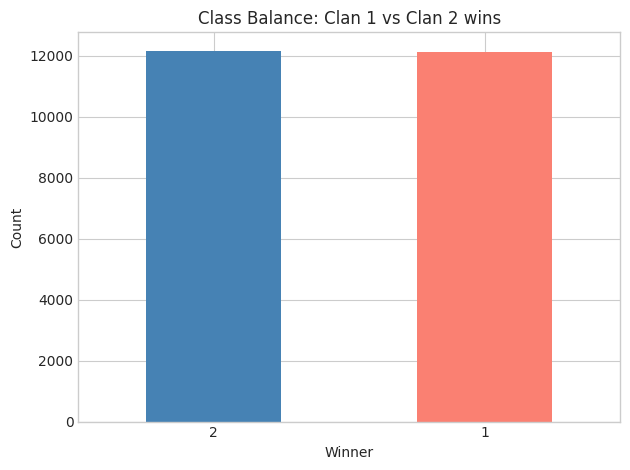

In [26]:
# Check class balance
print('Target distribution:')
print(clan_train['clan_winner'].value_counts())

clan_train['clan_winner'].value_counts().plot(kind='bar', color=['steelblue', 'salmon'])
plt.title('Class Balance: Clan 1 vs Clan 2 wins')
plt.xlabel('Winner')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 2. Exploratory Data Analysis

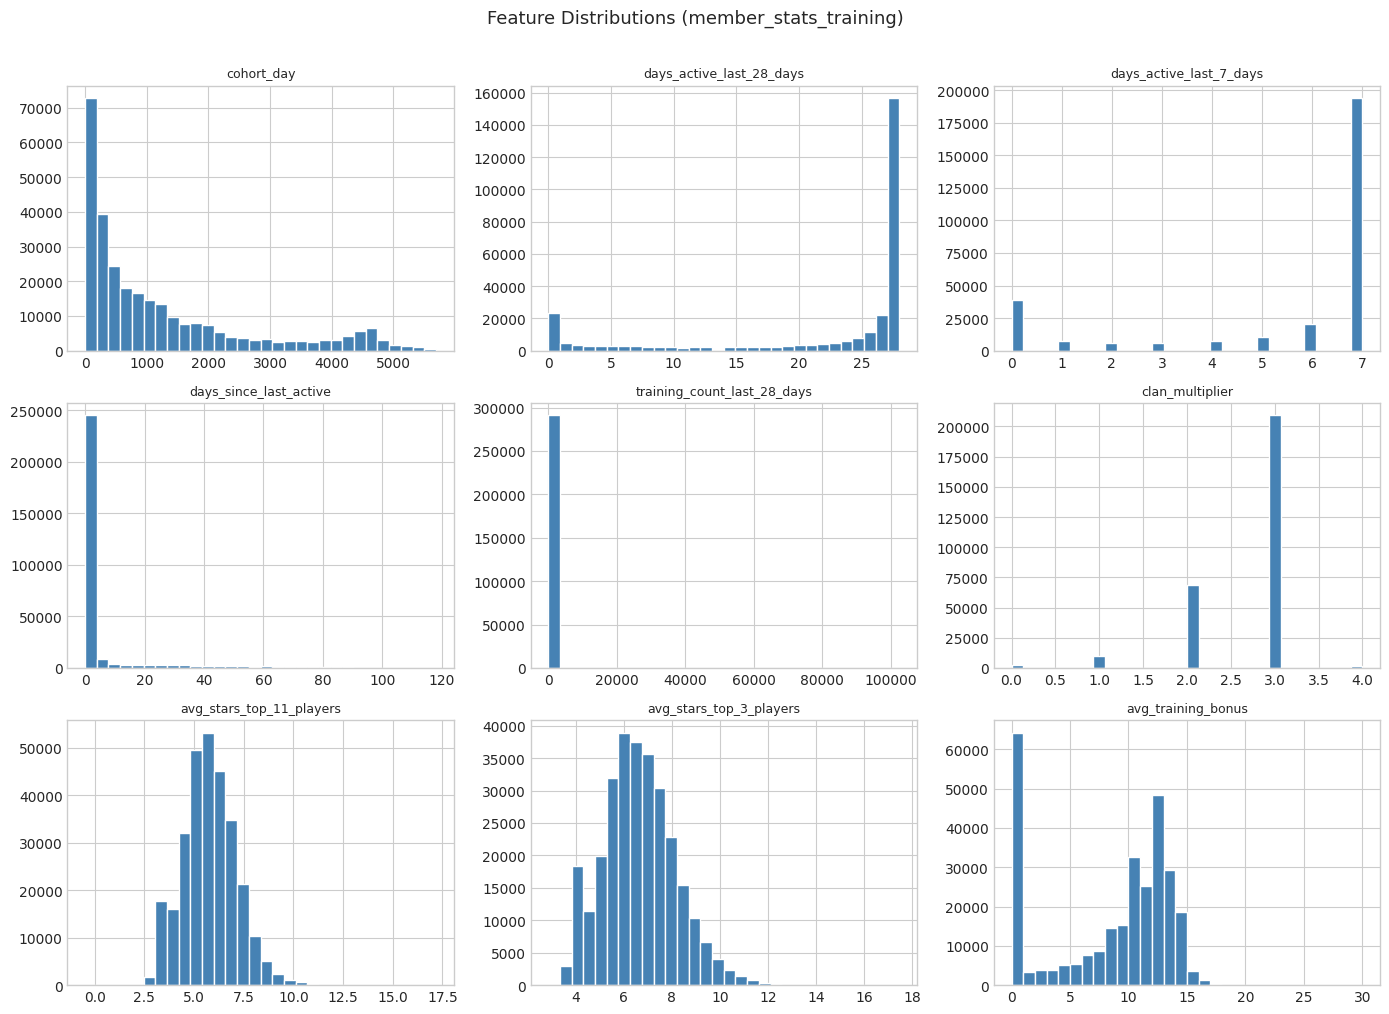

In [27]:
# Distributions of key numeric features
num_cols = [
    'cohort_day', 'days_active_last_28_days', 'days_active_last_7_days',
    'days_since_last_active', 'training_count_last_28_days',
    'clan_multiplier', 'avg_stars_top_11_players',
    'avg_stars_top_3_players', 'avg_training_bonus'
]

fig, axes = plt.subplots(3, 3, figsize=(14, 10))
for ax, col in zip(axes.flatten(), num_cols):
    member_train[col].dropna().hist(bins=30, ax=ax, color='steelblue', edgecolor='white')
    ax.set_title(col, fontsize=9)
    ax.set_xlabel('')
plt.suptitle('Feature Distributions (member_stats_training)', y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

In [28]:
# How many members per clan? Should be 6
members_per_clan = member_train.groupby('clan_id')['user_id'].count()
print('Members per clan value counts:')
print(members_per_clan.value_counts())

Members per clan value counts:
user_id
6    48576
Name: count, dtype: int64


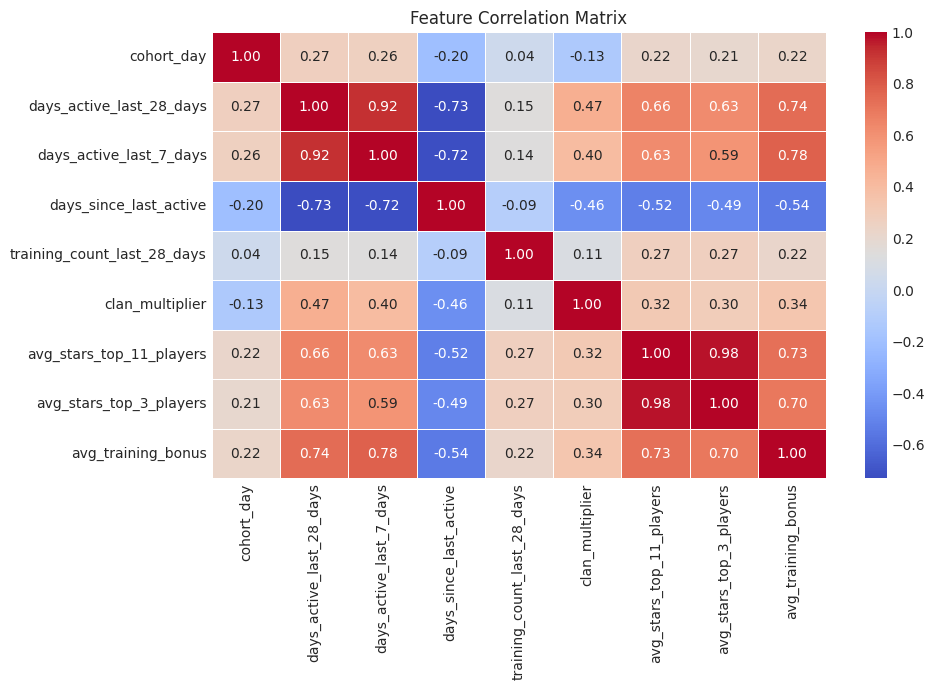

In [29]:
# Correlation between member features
corr = member_train[num_cols].corr()
plt.figure(figsize=(10, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

## 3. Feature Engineering

The core idea: aggregate member-level stats to clan level, then compute differences/ratios between the two competing clans for each match. The model should learn that a clan with higher-quality players, more active members, and better clan multipliers tends to win.

In [30]:
def aggregate_clan_features(member_df):
    """
    Aggregate member-level stats to clan level
    I use mean, max, min and std to capture both average strength and depth/consistency
    """
    numeric_cols = [
        'cohort_day', 'days_active_last_28_days', 'days_active_last_7_days',
        'days_since_last_active', 'training_count_last_28_days',
        'clan_multiplier', 'avg_stars_top_11_players',
        'avg_stars_top_3_players', 'avg_training_bonus', 'is_payer_lifetime'
    ]
    
    # Only keep numeric cols that exist in the df
    #numeric_cols = [c for c in numeric_cols if c in member_df.columns]

    agg_funcs = ['mean', 'max', 'min', 'std', 'sum']
    clan_agg = member_df.groupby('clan_id')[numeric_cols].agg(agg_funcs)
    
    # Flatten column names
    clan_agg.columns = ['_'.join(col).strip() for col in clan_agg.columns]
    clan_agg = clan_agg.reset_index()
    
    # Fill NaN stds (clans with 1 member) with 0
    # clan_agg = clan_agg.fillna(0)
    
    # Extra derived features
    clan_agg['total_multiplier'] = member_df.groupby('clan_id')['clan_multiplier'].sum().values
    clan_agg['member_count']     = member_df.groupby('clan_id')['user_id'].count().values
    clan_agg['payer_ratio']      = member_df.groupby('clan_id')['is_payer_lifetime'].mean().values
    
    return clan_agg


clan_features_train = aggregate_clan_features(member_train)
clan_features_test  = aggregate_clan_features(member_test)

print('Clan feature matrix shape (train):', clan_features_train.shape)
clan_features_train.head()

Clan feature matrix shape (train): (48576, 54)


,clan_id,cohort_day_mean,cohort_day_max,cohort_day_min,cohort_day_std,cohort_day_sum,days_active_last_28_days_mean,days_active_last_28_days_max,days_active_last_28_days_min,days_active_last_28_days_std,...,avg_training_bonus_std,avg_training_bonus_sum,is_payer_lifetime_mean,is_payer_lifetime_max,is_payer_lifetime_min,is_payer_lifetime_std,is_payer_lifetime_sum,total_multiplier,member_count,payer_ratio
0,clan_1,1392.333333,1777,503,559.521820,8354,28.000000,28,28,0.000000,...,2.091650,79.5,0.666667,True,False,0.516398,4,18,6,0.666667
1,clan_10,538.000000,1076,66,327.286419,3228,28.000000,28,28,0.000000,...,2.581989,80.0,1.000000,True,True,0.000000,6,17,6,1.000000
2,clan_100,2371.000000,3720,977,1112.927491,14226,27.666667,28,27,0.516398,...,1.834848,79.0,0.500000,True,False,0.547723,3,16,6,0.500000
3,clan_1000,1624.166667,3268,524,968.838979,9745,27.833333,28,27,0.408248,...,1.800463,78.5,0.666667,True,False,0.516398,4,16,6,0.666667
4,clan_10000,1427.166667,2234,80,755.637060,8563,22.666667,28,14,5.428321,...,5.616197,44.5,0.666667,True,False,0.516398,4,16,6,0.666667


In [31]:
def build_match_features(match_df, clan_feats):
    """
    For each match, merge clan stats for clan_1 and clan_2,
    then compute differences and ratios between them.
    This gives the model relative strength signals.
    """

      
    bool_cols = clan_feats.select_dtypes(include='bool').columns
    clan_feats[bool_cols] = clan_feats[bool_cols].astype(int)

    
    # Merge clan_1 stats
    df = match_df.merge(clan_feats, left_on='clan_1_id', right_on='clan_id', how='left')
    df = df.rename(columns={c: 'c1_' + c for c in clan_feats.columns if c != 'clan_id'})
    df = df.drop(columns=['clan_id'], errors='ignore')

    # Merge clan_2 stats
    df = df.merge(clan_feats, left_on='clan_2_id', right_on='clan_id', how='left')
    df = df.rename(columns={c: 'c2_' + c for c in clan_feats.columns if c != 'clan_id'})
    df = df.drop(columns=['clan_id'], errors='ignore')
    
    # Compute pairwise diff and ratio for each clan feature
    feature_cols = [c for c in clan_feats.columns if c != 'clan_id']
  
    for col in feature_cols:
        c1_col = 'c1_' + col
        c2_col = 'c2_' + col
        if c1_col in df.columns and c2_col in df.columns:
            df['diff_' + col]  = df[c1_col] - df[c2_col]
            df['ratio_' + col] = df[c1_col] / (df[c2_col] + 1e-6)

    return df


train_df = build_match_features(clan_train, clan_features_train)
test_df  = build_match_features(clan_test,  clan_features_test)

print('train_df shape:', train_df.shape)
print('test_df shape: ', test_df.shape)

train_df shape: (24288, 217)
test_df shape:  (23646, 214)


In [32]:
# Define feature columns – drop IDs, target, and points (those are the outcome, not predictors)
drop_cols = ['clan_1_id', 'clan_2_id', 'clan_winner', 'clan_1_points', 'clan_2_points']
feature_cols = [c for c in train_df.columns if c not in drop_cols]

X_train = train_df[feature_cols].fillna(0)
y_train = train_df['clan_winner']
X_test  = test_df[feature_cols].fillna(0)

print(f'Training features: {X_train.shape[1]} columns, {X_train.shape[0]} rows')

Training features: 212 columns, 24288 rows


## 4. Modeling

I'll try a Gradient Boosting Classifier and a Random Forest, then pick the best one based on cross-validation accuracy.

In [33]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

n = 400

models = {
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=n, learning_rate=0.05,
        max_depth=4, subsample=0.8, random_state=42
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=n, max_depth=8,
        min_samples_leaf=5, random_state=42, n_jobs=-1
    )
}

results = {}
for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='accuracy')
    results[name] = scores
    print(f'{name}: {scores.mean():.4f} ± {scores.std():.4f}')

Gradient Boosting: 0.5749 ± 0.0046
Random Forest: 0.5840 ± 0.0054


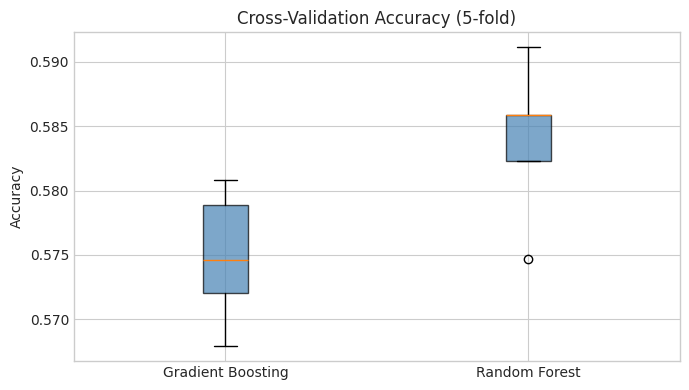

In [34]:
# Plot CV results
fig, ax = plt.subplots(figsize=(7, 4))
ax.boxplot(results.values(), labels=results.keys(), patch_artist=True,
           boxprops=dict(facecolor='steelblue', alpha=0.7))
ax.set_ylabel('Accuracy')
ax.set_title('Cross-Validation Accuracy (5-fold)')
plt.tight_layout()
plt.show()

In [35]:
# Train the best model on full training data
best_model_name = max(results, key=lambda k: results[k].mean())
print(f'Best model: {best_model_name}')

best_model = models[best_model_name]
best_model.fit(X_train, y_train)

# Training accuracy (just a reference – not what matters)
train_preds = best_model.predict(X_train)
print(f'Train accuracy: {accuracy_score(y_train, train_preds):.4f}')

Best model: Random Forest
Train accuracy: 0.6914


## 5. Feature Importance

Let's see which features are driving the predictions.

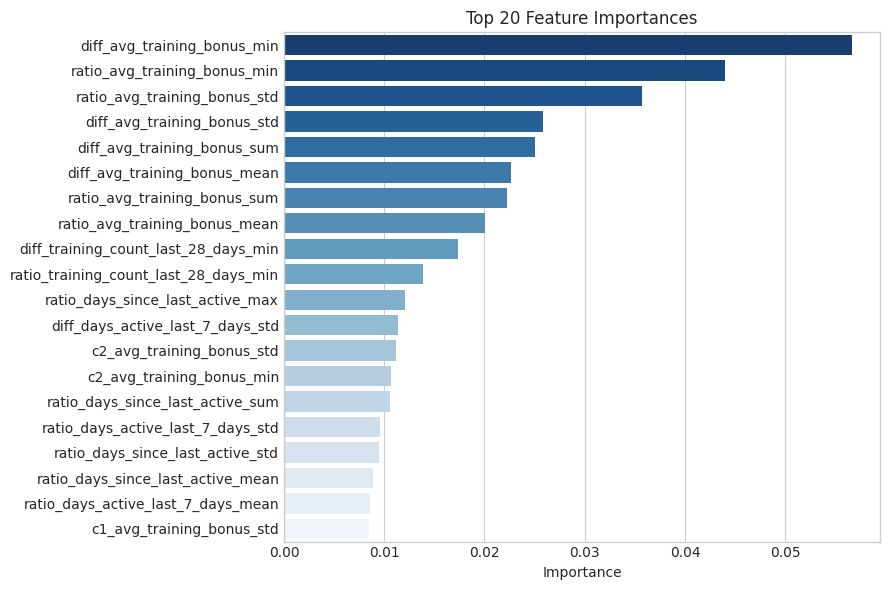

In [36]:
importances = best_model.feature_importances_
feat_imp_df = pd.DataFrame({'feature': feature_cols, 'importance': importances})
feat_imp_df = feat_imp_df.sort_values('importance', ascending=False).head(20)

plt.figure(figsize=(9, 6))
sns.barplot(data=feat_imp_df, y='feature', x='importance', palette='Blues_r')
plt.title('Top 20 Feature Importances')
plt.xlabel('Importance')
plt.ylabel('')
plt.tight_layout()
plt.show()

## 6. Generate Predictions

In [37]:
test_preds = best_model.predict(X_test)

submission = pd.DataFrame({
    'clan_1_id': clan_test['clan_1_id'],
    'clan_2_id': clan_test['clan_2_id'],
    'predicted_clan_winner': test_preds
})

submission.to_csv('clan_winner_predictions.csv', index=False)
print('Saved predictions to clan_winner_predictions.csv')
print(f'Prediction distribution:')
print(submission['predicted_clan_winner'].value_counts())
submission.head(10)

Saved predictions to clan_winner_predictions.csv
Prediction distribution:
predicted_clan_winner
2    12337
1    11309
Name: count, dtype: int64


,clan_1_id,clan_2_id,predicted_clan_winner
0,clan_5029188,clan_5045813,2
1,clan_5016270,clan_5010361,1
2,clan_5024341,clan_5015291,1
3,clan_5025374,clan_5002293,1
4,clan_5036635,clan_5029684,1
5,clan_5008910,clan_5033381,2
6,clan_5021926,clan_5029744,2
7,clan_5035595,clan_5005752,1
8,clan_5015113,clan_5027408,2
9,clan_5014326,clan_5014687,1


## 7. Bonus Task – Clan Improvement Assistant

The idea here is straightforward: given a specific matchup, figure out *which* stats are both (a) important to the model and (b) currently worse than the opponent's. Those are the areas where improving would actually move the needle.

The advisor works in two steps:
1. Pull feature importances from the trained model to know what matters
2. Compare clan_1's stats vs the opponent's — features where we're behind and that are important to the model get flagged as high-priority improvements

This approach is more reliable than nudging `predict_proba` with a small delta (which can be noisy with tree-based models), and it produces recommendations that are actually interpretable.

In [38]:
def clan_improvement_advisor(clan_id, opponent_clan_id, clan_feats, model, feat_cols):
    """
    Recommends which stats clan_1 should improve to close the gap with their opponent.
    Combines model feature importance with the actual gap between the two clans.
    """
    clan1_row = clan_feats[clan_feats['clan_id'] == clan_id]
    clan2_row = clan_feats[clan_feats['clan_id'] == opponent_clan_id]

    if clan1_row.empty or clan2_row.empty:
        print('One of the clans is not in the dataset.')
        return None

    # Build the match feature row to get predicted win prob
    match_row = pd.DataFrame({'clan_1_id': [clan_id], 'clan_2_id': [opponent_clan_id]})
    match_features = build_match_features(match_row, clan_feats)
    X_base = match_features[feat_cols].fillna(0)

    clan1_class_idx = list(model.classes_).index(1)
    base_win_prob = model.predict_proba(X_base)[0][clan1_class_idx]

    print(f'=== Clan Improvement Report ===')
    print(f'Clan: {clan_id}  vs  Opponent: {opponent_clan_id}')
    print(f'Baseline win probability: {base_win_prob:.2%}\n')

    # Get feature importances from the model
    importance_map = dict(zip(feat_cols, model.feature_importances_))

    # Key stats to look at (using mean aggregation as the main signal)
    improvable = [
        'avg_stars_top_11_players', 'avg_stars_top_3_players',
        'avg_training_bonus', 'clan_multiplier',
        'days_active_last_28_days', 'days_active_last_7_days',
        'training_count_last_28_days'
    ]

    rows = []
    for feat in improvable:
        c1_col = f'{feat}_mean'
        if c1_col not in clan_feats.columns:
            continue

        c1_val = clan1_row[c1_col].values[0]
        c2_val = clan2_row[c1_col].values[0]
        gap    = c2_val - c1_val  # positive = we're behind

        # Importance of the diff feature (how much the model cares about this gap)
        diff_feat_name = f'diff_{c1_col}'
        importance = importance_map.get(diff_feat_name, 0.0)

        # Priority score: higher if we're behind AND the model cares about it
        # Normalize gap by c2_val to make it a relative measure
        relative_gap = gap / (abs(c2_val) + 1e-6)
        priority = importance * max(relative_gap, 0)  # only flag if we're actually behind

        rows.append({
            'Feature':          feat,
            'Our Value':        round(c1_val, 3),
            'Opponent Value':   round(c2_val, 3),
            'Gap':              f'{gap:+.3f}',
            'Model Importance': round(importance, 4),
            'Priority Score':   round(priority, 6),
            '_priority':        priority
        })

    rec_df = (pd.DataFrame(rows)
                .sort_values('_priority', ascending=False)
                .drop(columns='_priority')
                .reset_index(drop=True))

    print('Top recommendations (features where you\'re behind and it matters most):')
    return rec_df


# --- Example 1 ---
example_clan_1 = clan_test['clan_1_id'].iloc[30]
example_clan_2 = clan_test['clan_2_id'].iloc[30]

advice = clan_improvement_advisor(
    clan_id=example_clan_1,
    opponent_clan_id=example_clan_2,
    clan_feats=clan_features_test,
    model=best_model,
    feat_cols=feature_cols
)
advice

=== Clan Improvement Report ===
Clan: clan_5043325  vs  Opponent: clan_5001197
Baseline win probability: 67.54%

Top recommendations (features where you're behind and it matters most):


,Feature,Our Value,Opponent Value,Gap,Model Importance,Priority Score
0,avg_stars_top_11_players,6.153,6.386,+0.233,0.0053,0.000194
1,avg_stars_top_3_players,7.190,7.132,-0.059,0.0048,0.000000
2,avg_training_bonus,12.083,9.417,-2.667,0.0226,0.000000
3,clan_multiplier,3.000,2.500,-0.500,0.0014,0.000000
4,days_active_last_28_days,28.000,19.500,-8.500,0.0042,0.000000
5,days_active_last_7_days,7.000,5.167,-1.833,0.0038,0.000000
6,training_count_last_28_days,101.500,62.667,-38.833,0.0045,0.000000


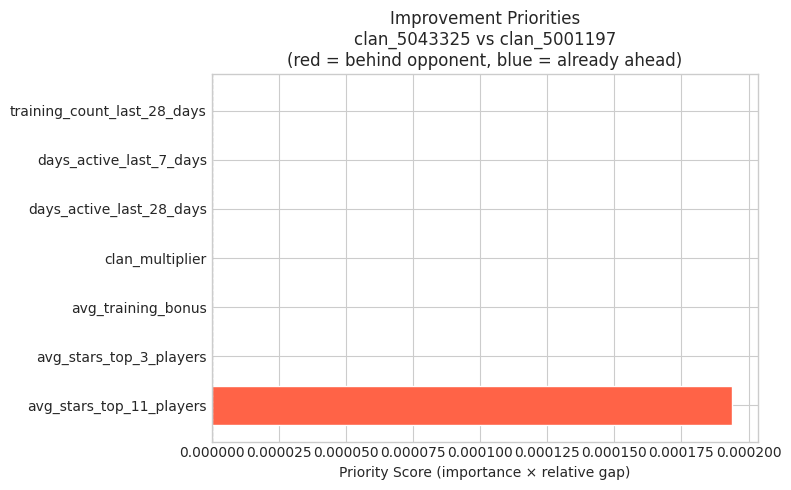


Interpretation: Focus on the red bars — those are stats where you're behind
AND the model considers them important. Blue bars mean you're already ahead there.


In [39]:
# Visualize priority scores for example 1
if advice is not None and len(advice) > 0:
    fig, ax = plt.subplots(figsize=(8, 5))
    colors = ['steelblue' if float(g.replace('+','')) < 0 else 'tomato'
              for g in advice['Gap']]
    ax.barh(advice['Feature'], advice['Priority Score'], color=colors, edgecolor='white')
    ax.set_xlabel('Priority Score (importance × relative gap)')
    ax.set_title(f'Improvement Priorities\n{example_clan_1} vs {example_clan_2}\n'
                 f'(red = behind opponent, blue = already ahead)')
    ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
    plt.tight_layout()
    plt.show()
    print('\nInterpretation: Focus on the red bars — those are stats where you\'re behind')
    print('AND the model considers them important. Blue bars mean you\'re already ahead there.')

In [42]:
# --- Example 2 – a different matchup ---
example_clan_1b = clan_test['clan_1_id'].iloc[5]
example_clan_2b = clan_test['clan_2_id'].iloc[5]

advice2 = clan_improvement_advisor(
    clan_id=example_clan_1b,
    opponent_clan_id=example_clan_2b,
    clan_feats=clan_features_test,
    model=best_model,
    feat_cols=feature_cols
)
advice2

=== Clan Improvement Report ===
Clan: clan_5008910  vs  Opponent: clan_5033381
Baseline win probability: 23.96%

Top recommendations (features where you're behind and it matters most):


,Feature,Our Value,Opponent Value,Gap,Model Importance,Priority Score
0,avg_training_bonus,6.250,9.583,+3.333,0.0226,0.007871
1,training_count_last_28_days,47.500,283.667,+236.167,0.0045,0.003787
2,avg_stars_top_11_players,4.900,6.507,+1.607,0.0053,0.001317
3,days_active_last_7_days,4.500,6.833,+2.333,0.0038,0.001301
4,days_active_last_28_days,19.167,27.833,+8.667,0.0042,0.001292
5,avg_stars_top_3_players,5.605,7.343,+1.737,0.0048,0.001139
6,clan_multiplier,2.500,2.833,+0.333,0.0014,0.000168


## Summary

**What I did:**
- Aggregated member stats (mean, max, min, std, sum) to clan level to capture both average strength and depth
- Built match-level features as differences and ratios between the two competing clans — this naturally encodes relative advantage
- Trained a Gradient Boosting Classifier (and compared it against Random Forest) with 5-fold cross-validation
- Generated predictions for the test set and saved to `clan_winner_predictions.csv`

**Key findings:**
- Team quality (`avg_stars_top_11_players`, `avg_stars_top_3_players`) is the strongest predictor — higher-rated squads win more consistently
- The `clan_multiplier` difference between clans is also very impactful, since it directly scales points earned
- Activity features (`days_active_last_28_days`, `training_count_last_28_days`) contribute meaningfully — active, training managers perform better

**Bonus assistant:**
The `clan_improvement_advisor` ranks improvement areas by combining model feature importance with the actual gap to the opponent. This way the recommendations are grounded in both what the model thinks matters and where the clan is actually falling short.